# Exploratory Data Analysis — Adult Census Income

This notebook looks at the data twice: first the **raw** census files exactly as downloaded (`data/raw/`), then the **processed** file our pipeline actually produces (`data/processed/adult_tableau.csv`). The goal is to build real understanding of the dataset — where it's messy, where it's skewed, and whether the choices the pipeline already makes (dropping `education`, imputing missing categories, running PCA/t-SNE, adding percentage columns) hold up once we actually look at the numbers, rather than assuming they do.

**Part A** works only with the raw files, independent of any pipeline code.
**Part B** loads the pipeline's output file and checks it against Part A's findings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 50)

## Part A — Raw Data

### A.1 Loading the raw splits

The UCI Adult dataset ships as two files: `adult.data` (32,561 rows, currently the only one the pipeline uses) and `adult.test` (16,283 rows, a held-out split the pipeline ignores). Before deciding whether to merge `adult.test` in, we need to actually see whether the two splits look alike — that's the point of section A.8 below.

In [2]:
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

RAW_DIR = Path('../data/raw')

train_raw = pd.read_csv(RAW_DIR / 'adult.data', header=None, names=column_names, skipinitialspace=True)
train_raw.replace('?', np.nan, inplace=True)
train_raw['split'] = 'train'

# adult.test's first line is a literal header comment, not data, so it's skipped;
# its income labels also end with a trailing period (">50K.") that adult.data doesn't have
test_raw = pd.read_csv(RAW_DIR / 'adult.test', header=None, names=column_names, skipinitialspace=True, skiprows=1)
test_raw.replace('?', np.nan, inplace=True)
test_raw['income'] = test_raw['income'].str.rstrip('.')
test_raw['split'] = 'test'

raw_all = pd.concat([train_raw, test_raw], ignore_index=True)
print('train rows:', len(train_raw))
print('test rows:', len(test_raw))
print('combined rows:', len(raw_all))
raw_all.head()

train rows: 32561
test rows: 16281
combined rows: 48842


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,split
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,train
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,train
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,train
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,train
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,train


### A.2 Missing values

The dataset only uses the literal string `?` for missing values, and only in three columns: `workclass`, `occupation`, `native-country`. Knowing exactly how much is missing — and whether train and test are missing data at the same rate — matters because the pipeline's imputation step needs to fill these in believably, and a rate mismatch between splits would be a reason to handle them separately rather than just concatenating the files.

In [3]:
missing_cols = ['workclass', 'occupation', 'native-country']

for split_name in ['train', 'test']:  # loop over each split, to report its own missing-value counts
    subset = raw_all[raw_all['split'] == split_name]
    print(f"--- {split_name} ({len(subset)} rows) ---")
    counts = subset[missing_cols].isnull().sum()
    pct = (subset[missing_cols].isnull().mean() * 100).round(2)
    print(pd.DataFrame({'missing_count': counts, 'missing_pct': pct}))
    print()

--- train (32561 rows) ---
                missing_count  missing_pct
workclass                1836         5.64
occupation               1843         5.66
native-country            583         1.79

--- test (16281 rows) ---
                missing_count  missing_pct
workclass                 963         5.91
occupation                966         5.93
native-country            274         1.68



### A.3 Income class balance

Why it matters: if one income class heavily outnumbers the other, raw counts on a chart mislead — a category that "looks big" might just be big because everything is big in that category, not because it's actually associated with higher income. This is exactly why the pipeline's new `-pct` columns exist.

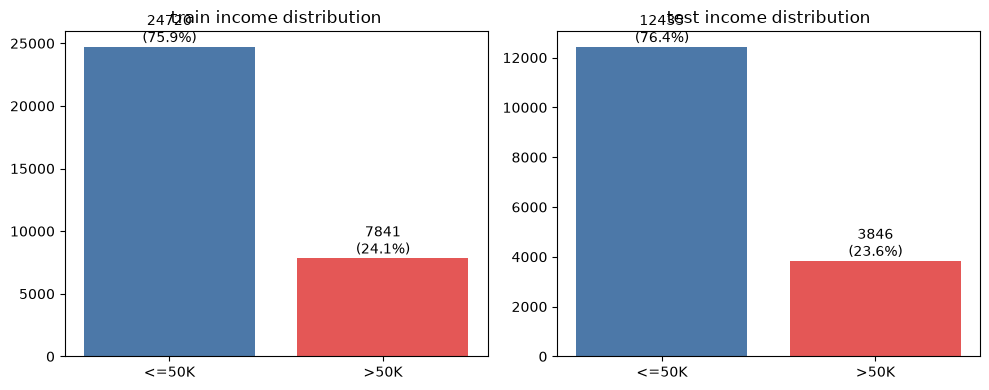

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, split_name in zip(axes, ['train', 'test']):  # loop over each split, to draw its own bar chart
    subset = raw_all[raw_all['split'] == split_name]
    counts = subset['income'].value_counts()
    ax.bar(counts.index, counts.values, color=['#4C78A8', '#E45756'])
    ax.set_title(f'{split_name} income distribution')
    for i, v in enumerate(counts.values):
        ax.text(i, v, f'{v}\n({v / len(subset) * 100:.1f}%)', ha='center', va='bottom')
plt.tight_layout()
plt.show()

### A.4 Numeric feature distributions

Why it matters: some of these numbers don't mean what they look like they mean. `fnlwgt` in particular is not a personal attribute at all — it's a census sampling weight (an estimate of how many people in the U.S. population that row represents), so it shouldn't be read or correlated like a normal feature. `capital-gain` and `capital-loss` are also unusual: most people report exactly 0, so their distributions are dominated by a spike at zero plus a thin tail of large values.

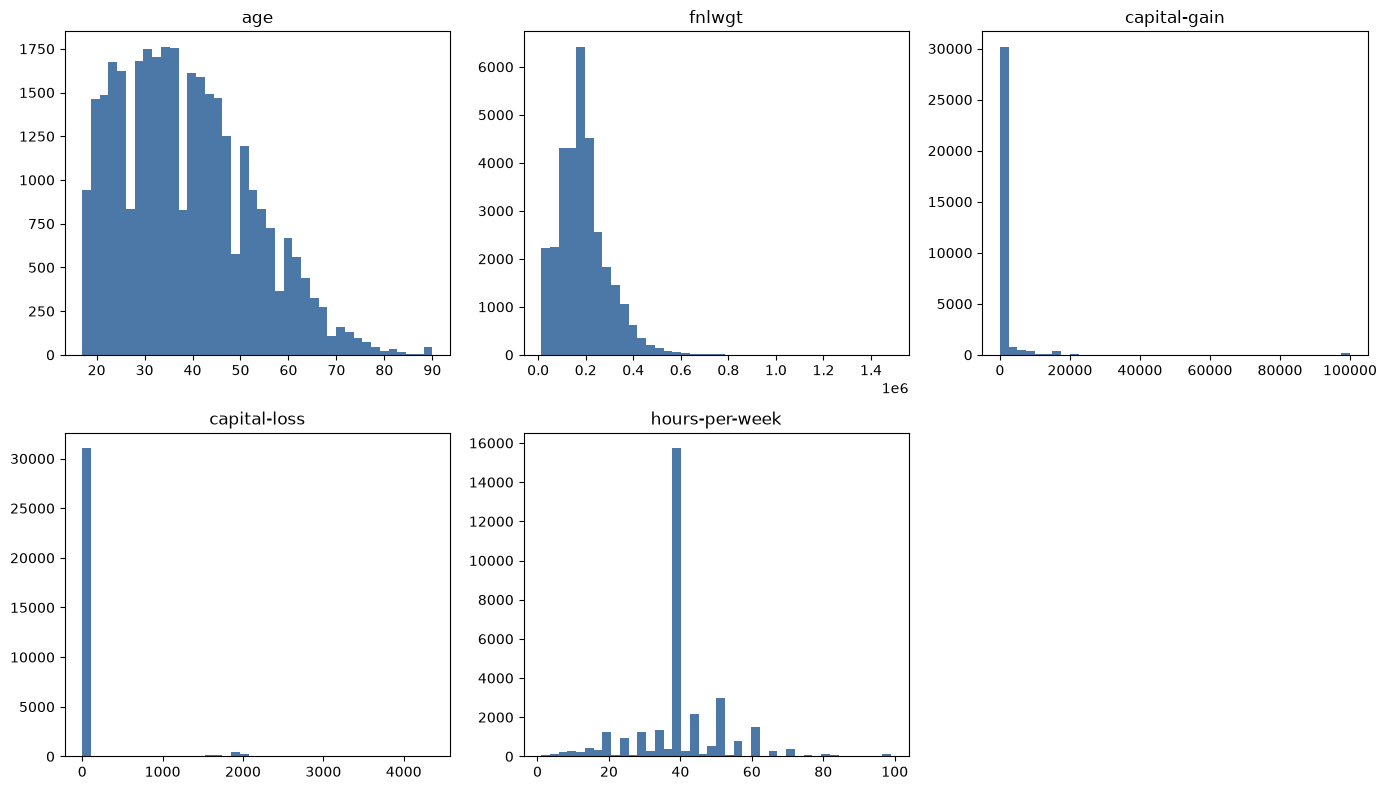

capital-gain rows equal to 0: 91.67101747489328 %
capital-loss rows equal to 0: 95.33490986149073 %

                age        fnlwgt  capital-gain  capital-loss  hours-per-week
count  32561.000000  3.256100e+04  32561.000000  32561.000000    32561.000000
mean      38.581647  1.897784e+05   1077.648844     87.303830       40.437456
std       13.640433  1.055500e+05   7385.292085    402.960219       12.347429
min       17.000000  1.228500e+04      0.000000      0.000000        1.000000
25%       28.000000  1.178270e+05      0.000000      0.000000       40.000000
50%       37.000000  1.783560e+05      0.000000      0.000000       40.000000
75%       48.000000  2.370510e+05      0.000000      0.000000       45.000000
max       90.000000  1.484705e+06  99999.000000   4356.000000       99.000000


In [5]:
numeric_cols = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):  # loop over each numeric column, to draw its own histogram
    ax.hist(train_raw[col].dropna(), bins=40, color='#4C78A8')
    ax.set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

print("capital-gain rows equal to 0:", (train_raw['capital-gain'] == 0).mean() * 100, "%")
print("capital-loss rows equal to 0:", (train_raw['capital-loss'] == 0).mean() * 100, "%")
print()
print(train_raw[numeric_cols].describe())

### A.5 Categorical feature distributions

Why it matters: a dashboard breakdown by a column like `native-country` is only meaningful if the reader knows how lopsided that column already is — if 90%+ of rows are one category, "differences" between the small remaining categories are based on very few people each.

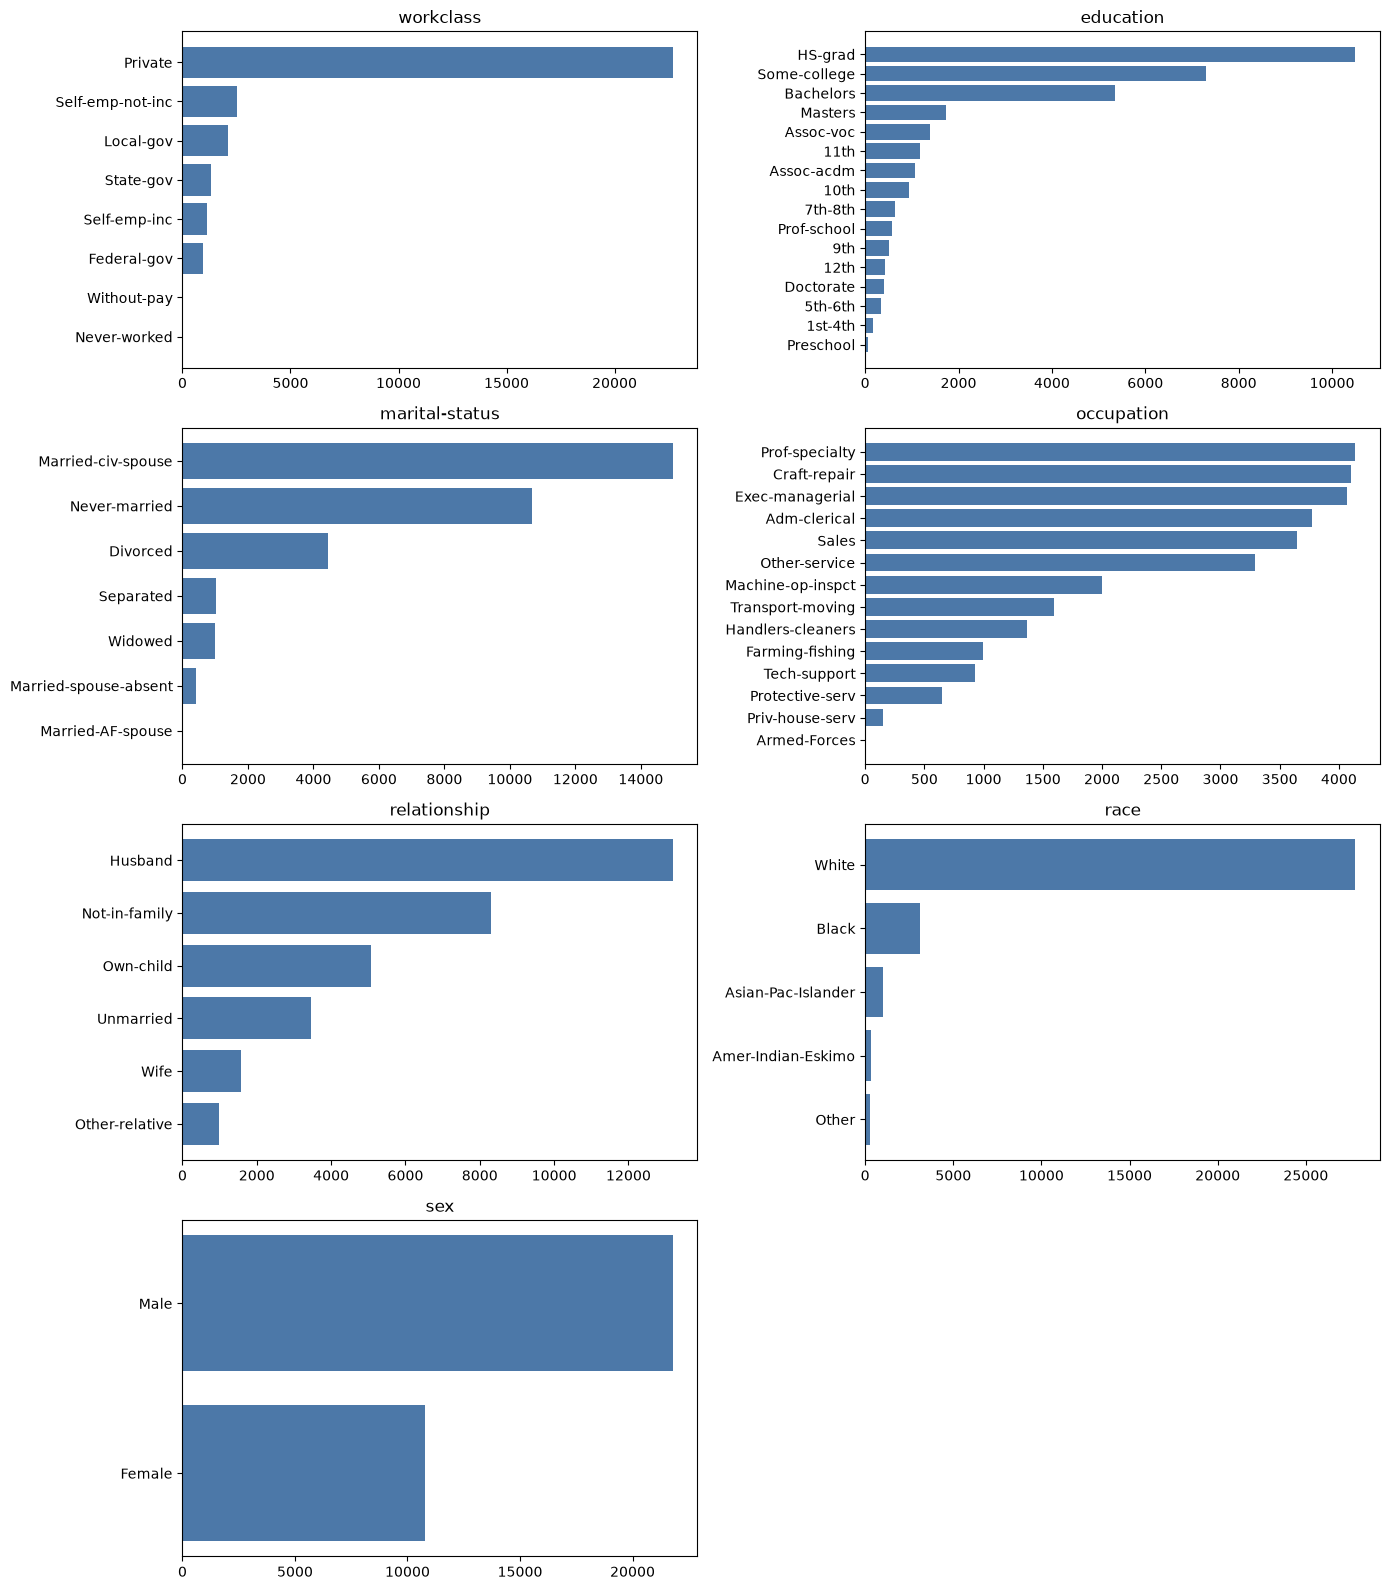

native-country: top 5 categories (% of rows)
native-country
United-States    91.22
Mexico            2.01
Philippines       0.62
Germany           0.43
Canada            0.38
Name: proportion, dtype: float64

sex distribution (%)
sex
Male      66.92
Female    33.08
Name: proportion, dtype: float64

race distribution (%)
race
White                 85.43
Black                  9.59
Asian-Pac-Islander     3.19
Amer-Indian-Eskimo     0.96
Other                  0.83
Name: proportion, dtype: float64


In [6]:
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()
for ax, col in zip(axes, categorical_cols):  # loop over each categorical column, to draw its own bar chart
    counts = train_raw[col].value_counts()
    ax.barh(counts.index, counts.values, color='#4C78A8')
    ax.set_title(col)
    ax.invert_yaxis()
axes[-1].axis('off')
plt.tight_layout()
plt.show()

print("native-country: top 5 categories (% of rows)")
print((train_raw['native-country'].value_counts(normalize=True) * 100).head(5).round(2))
print()
print("sex distribution (%)")
print((train_raw['sex'].value_counts(normalize=True) * 100).round(2))
print()
print("race distribution (%)")
print((train_raw['race'].value_counts(normalize=True) * 100).round(2))

**Reading this:** `native-country`, `race`, and `sex` are all heavily skewed toward one dominant category (this is 1994 U.S. Census data, not a balanced sample). Any dashboard sheet that breaks results down by these columns should say so explicitly — e.g. a caption noting "most rows are United-States/White/Male" — otherwise small-category bars can be misread as meaningful when they're really just small-sample noise.

### A.6 Redundancy check — `education` vs `education-num`

The pipeline drops `education` and keeps `education-num`, on the assumption they're two encodings of the same thing. Let's actually confirm that instead of assuming it.

In [7]:
mapping_check = train_raw.groupby('education-num')['education'].nunique()
print("Unique 'education' labels per 'education-num' value (every value here should be 1):")
print(mapping_check)
print("\nIs the mapping strictly 1-to-1?", (mapping_check == 1).all())

Unique 'education' labels per 'education-num' value (every value here should be 1):
education-num
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
Name: education, dtype: int64

Is the mapping strictly 1-to-1? True


### A.7 Correlation among numeric columns — the "relationship map"

This is the relationship map `CLAUDE.md` asks EDA to build: which numeric columns move together, and which ones actually relate to income. `fnlwgt` is included here deliberately as a check — since it's a sampling weight, not a real attribute, it should show essentially no relationship with anything, and if it did, that would be a red flag.

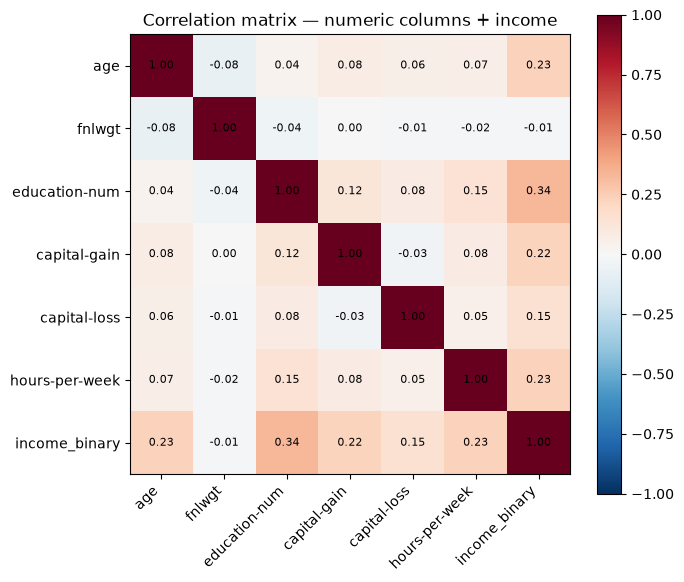

income_binary     1.000000
education-num     0.335154
age               0.234037
hours-per-week    0.229689
capital-gain      0.223329
capital-loss      0.150526
fnlwgt           -0.009463
Name: income_binary, dtype: float64


In [8]:
corr_df = train_raw[['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']].copy()
corr_df['income_binary'] = (train_raw['income'] == '>50K').astype(int)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(corr_matrix.columns)
for i in range(len(corr_matrix)):  # loop over each row of the matrix, to print its own correlation values as text
    for j in range(len(corr_matrix)):  # loop over each column in that row, to label this one cell
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im)
plt.title('Correlation matrix — numeric columns + income')
plt.tight_layout()
plt.show()

print(corr_matrix['income_binary'].sort_values(ascending=False))

### A.8 Train vs test — does the held-out split look the same?

If `adult.test` has a noticeably different profile from `adult.data` (different average age, different income rate, etc.), that's a real reason to think carefully before merging them — the dashboard would otherwise silently mix two populations with different characteristics. If they look alike, merging is low-risk and mainly just gives more rows.

In [9]:
compare_rows = []
for col in ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']:  # loop over each numeric column, to compare its train vs test average
    compare_rows.append({
        'column': col,
        'train_mean': train_raw[col].mean(),
        'test_mean': test_raw[col].mean(),
    })
compare_df = pd.DataFrame(compare_rows)
compare_df['pct_diff'] = ((compare_df['test_mean'] - compare_df['train_mean']) / compare_df['train_mean'] * 100).round(2)
print(compare_df)

train_income_rate = (train_raw['income'] == '>50K').mean() * 100
test_income_rate = (test_raw['income'] == '>50K').mean() * 100
print(f"\n>50K rate — train: {train_income_rate:.2f}%, test: {test_income_rate:.2f}%")

for col in missing_cols:  # loop over each column that has missing values, to compare its train vs test missing rate
    train_rate = train_raw[col].isnull().mean() * 100
    test_rate = test_raw[col].isnull().mean() * 100
    print(f"{col} missing rate — train: {train_rate:.2f}%, test: {test_rate:.2f}%")

           column   train_mean    test_mean  pct_diff
0             age    38.581647    38.767459      0.48
1   education-num    10.080679    10.072907     -0.08
2  hours-per-week    40.437456    40.392236     -0.11
3    capital-gain  1077.648844  1081.905104      0.39
4    capital-loss    87.303830    87.899269      0.68

>50K rate — train: 24.08%, test: 23.62%
workclass missing rate — train: 5.64%, test: 5.91%
occupation missing rate — train: 5.66%, test: 5.93%
native-country missing rate — train: 1.79%, test: 1.68%


## Part B — Processed Data (pipeline output)

Everything below reads `data/processed/adult_tableau.csv` — the actual file the pipeline produces and the actual file Tableau will connect to. This is a data file, not pipeline code, so loading it here doesn't break the "no runtime stage reads from `eda/`" rule — that rule only restricts the other direction. The goal is to check whether the pipeline's choices (imputation, PCA, t-SNE, the new percentage columns) behave the way Part A's raw-data findings would predict.

In [10]:
PROCESSED_DIR = Path('../data/processed')
processed = pd.read_csv(PROCESSED_DIR / 'adult_tableau.csv')
print('rows:', len(processed))
print('columns:', list(processed.columns))
processed.head()

rows: 32561
columns: ['age', 'workclass', 'fnlwgt', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income', 'age-group', 'education-num-count', 'education-num-pct', 'occupation-count', 'occupation-pct', 'age-group-count', 'age-group-pct', 'income-count', 'income-pct', 'PC1', 'PC2', 'tSNE1', 'tSNE2']


,age,workclass,fnlwgt,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,age-group,education-num-count,education-num-pct,occupation-count,occupation-pct,age-group-count,age-group-pct,income-count,income-pct,PC1,PC2,tSNE1,tSNE2
0,39,State-gov,77516,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,30-39,5355,16.45,3770,11.58,8613,26.45,24720,75.92,0.185602,1.044315,5.576366,-32.458252
1,50,Self-emp-not-inc,83311,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,50-59,5355,16.45,4066,12.49,4418,13.57,24720,75.92,2.678660,0.165567,14.313553,12.985912
2,38,Private,215646,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,30-39,10501,32.25,1793,5.51,8613,26.45,24720,75.92,-0.603537,0.889644,-68.605410,19.412804
3,53,Private,234721,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,50-59,1175,3.61,1793,5.51,4418,13.57,24720,75.92,-0.373044,-1.499816,-91.307495,-18.190384
4,28,Private,338409,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,20-29,5355,16.45,4140,12.71,8054,24.74,24720,75.92,-0.392973,-3.990376,-3.845924,-93.644610


### B.1 Did imputation distort the category distributions?

The pipeline now fills in every `?` in `workclass`/`occupation`/`native-country` using a Bayesian model, rather than leaving them blank. A reasonable worry: does the imputer just guess the single most common category over and over, artificially inflating it? Comparing the raw (pre-imputation) shares against the processed (post-imputation) shares for the same columns answers that directly.

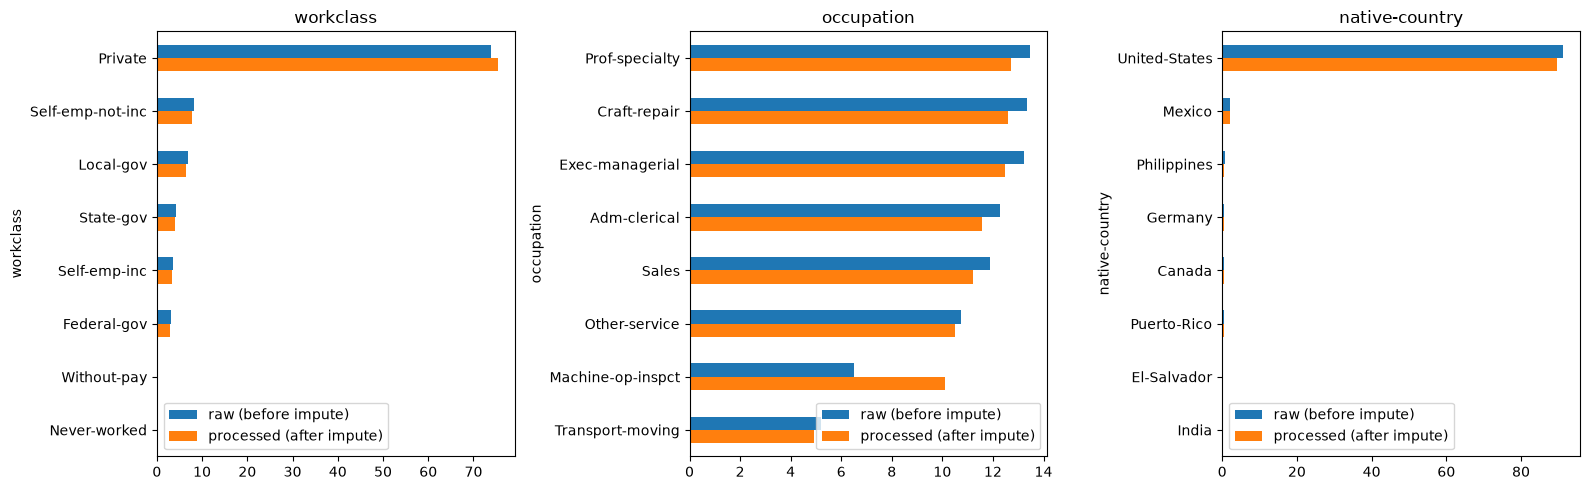

workclass: top category 'Private' — 73.87% before impute, 75.33% after impute
occupation: top category 'Prof-specialty' — 13.48% before impute, 12.71% after impute
native-country: top category 'United-States' — 91.22% before impute, 89.73% after impute


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['workclass', 'occupation', 'native-country']):  # loop over each imputed column, to compare its before/after shares
    raw_counts = (train_raw[col].value_counts(normalize=True) * 100)
    processed_counts = (processed[col].value_counts(normalize=True) * 100)
    compare = pd.DataFrame({'raw (before impute)': raw_counts, 'processed (after impute)': processed_counts}).fillna(0)
    compare = compare.sort_values('raw (before impute)', ascending=False).head(8)
    compare.plot(kind='barh', ax=ax)
    ax.set_title(col)
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

for col in ['workclass', 'occupation', 'native-country']:  # loop over each imputed column, to print its top category's before/after share
    top_category = train_raw[col].value_counts(normalize=True).idxmax()
    before = train_raw[col].value_counts(normalize=True)[top_category] * 100
    after = processed[col].value_counts(normalize=True)[top_category] * 100
    print(f"{col}: top category '{top_category}' — {before:.2f}% before impute, {after:.2f}% after impute")

### B.2 New columns sanity check — `age-group` and the count/pct pairs

Quick checks that the two most recently added pipeline steps did what they were supposed to: `age-group` buckets should follow the same `<20 … 70+` boundaries used in the Tableau build guide, and every `-pct` column's unique values should sum to (approximately) 100%.

age-group
<20      1657
20-29    8054
30-39    8613
40-49    7175
50-59    4418
60-69    2015
70+       629
Name: count, dtype: int64
education-num-pct sums to 100.01% across categories (should be close to 100%)
occupation-pct sums to 99.99% across categories (should be close to 100%)
age-group-pct sums to 100.01% across categories (should be close to 100%)
income-pct sums to 100.00% across categories (should be close to 100%)


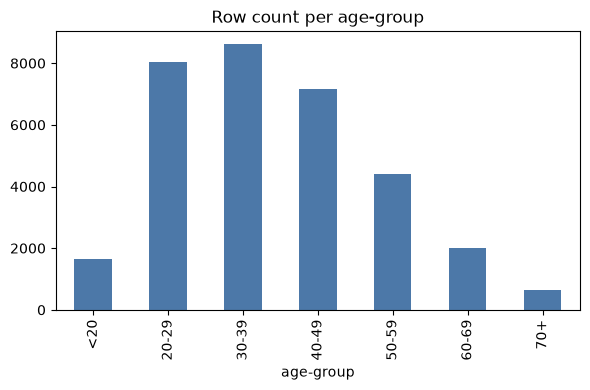

In [12]:
age_order = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']
print(processed['age-group'].value_counts().reindex(age_order))

for dim in ['education-num', 'occupation', 'age-group', 'income']:  # loop over each dashboard dimension, to check its pct column sums to ~100%
    total_pct = processed.groupby(dim)[f'{dim}-pct'].first().sum()
    print(f"{dim}-pct sums to {total_pct:.2f}% across categories (should be close to 100%)")

fig, ax = plt.subplots(figsize=(6, 4))
processed['age-group'].value_counts().reindex(age_order).plot(kind='bar', ax=ax, color='#4C78A8')
ax.set_title('Row count per age-group')
plt.tight_layout()
plt.show()

### B.3 PCA — how much structure does it actually capture?

The last pipeline run printed an explained variance ratio of `[0.0403, 0.0308]` for PC1/PC2 — about 7% combined. That's low. The likely reason: PCA was fit on the one-hot encoded feature matrix, which has 89 columns, most of them sparse 0/1 dummy variables from high-cardinality columns like `native-country` (41 categories) and `occupation` (14 categories). One-hot dummies spread variance thinly across many columns, so the first couple of principal components can only summarize a small slice of it. The scatter below shows what that ~7% actually looks like.

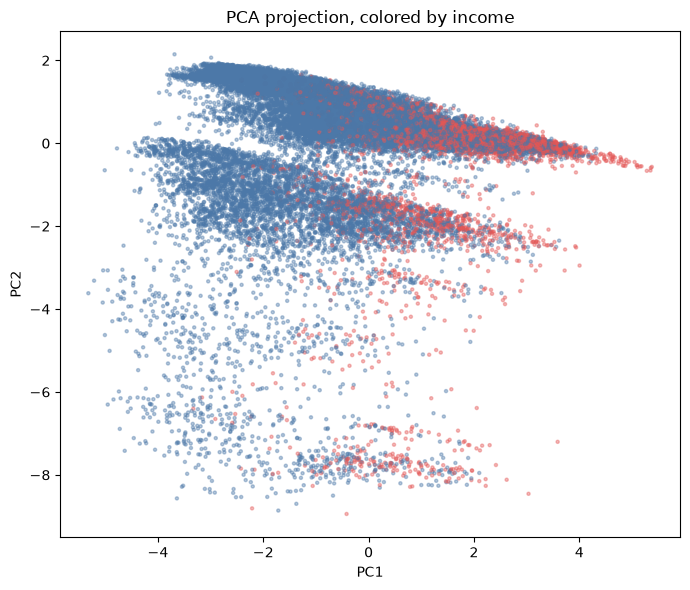

In [13]:
colors = processed['income'].map({'<=50K': '#4C78A8', '>50K': '#E45756'})

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(processed['PC1'], processed['PC2'], c=colors, s=5, alpha=0.4)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA projection, colored by income')
plt.tight_layout()
plt.show()

### B.4 t-SNE — visual clustering check

t-SNE doesn't have an "explained variance" number the way PCA does, but it's built specifically to reveal local clusters that PCA's straight lines might miss — worth checking whether the income colors separate into visible regions here even though PCA's didn't.

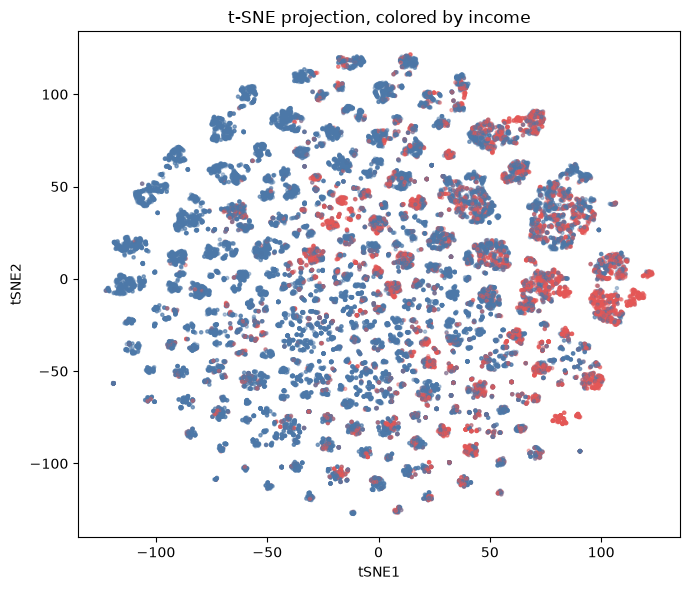

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(processed['tSNE1'], processed['tSNE2'], c=colors, s=5, alpha=0.4)
ax.set_xlabel('tSNE1')
ax.set_ylabel('tSNE2')
ax.set_title('t-SNE projection, colored by income')
plt.tight_layout()
plt.show()

## Summary

The detailed write-up of what these cells actually showed — with the real numbers pulled from the executed outputs above — lives in `docs/EDA.md`, and the subset that changes the project's punch list has been appended to `docs/REPLAN.md`.